In [14]:
import numpy as np
import matplotlib.pyplot as plt

from src.custom_functions import get_parameters_files, MSE
from src.data_loader import load_data
from src.data_manipulation import convert_model_to_data_shape
    
densities = np.arange(10,22,2,dtype=int)  
x_d = np.arange(75, 1875.1, 50)
x_m = np.arange(62.5, 1900,  25) 

## Artificial data

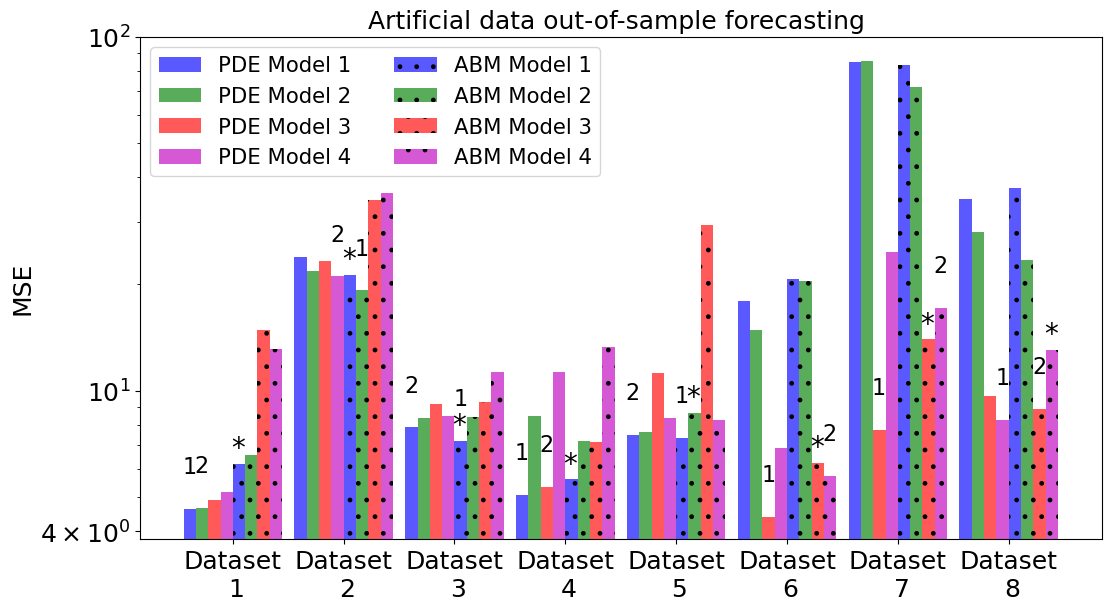

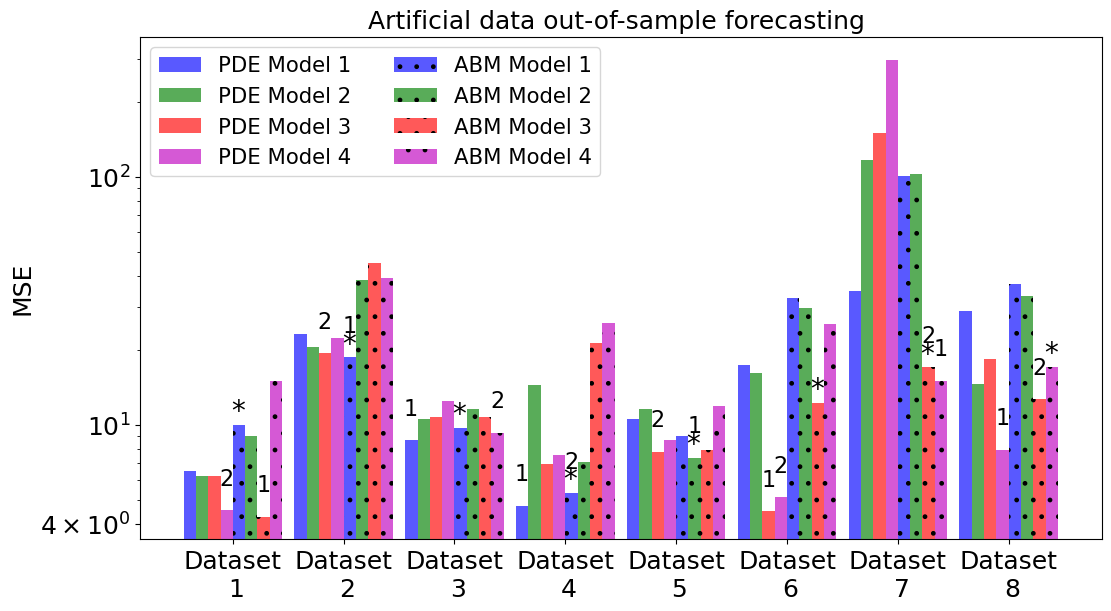

In [15]:
data_type = "artificial"
simulations = np.arange(8)
pred_type = "pred_final"
dens_ids = None
model_types = ["PDE","ABM"]
parameter_names = "rm_rp"
parameter_names_list = ["rm_rp","rm_pint_rp","rm_rp_a0_a1","rm_pint_rp_a0_a1"]
formatted_parameter_names = {"rm_rp":"Model 1","rm_pint_rp":"Model 2","rm_rp_a0_a1":"Model 3","rm_pint_rp_a0_a1":"Model 4"}
true_model_indices = [0,0,0,0,1,2,2,3]
best_model_indices_mean = [0,5,4,0,4,2,2,3]
second_best_model_indices_mean = [1, 3, 0, 2, 0, 7, 7, 6]
best_model_indices_map        = [6, 4, 0, 0, 5, 2, 7, 3]
second_best_model_indices_map = [3, 2, 7, 4, 2, 3, 6, 6]

num_models = len(parameter_names_list)

colors = "bgrm"
fontsize=18

for estimate_type in ["mean","MAP"]:
    
    # initialize figure
    fig,axes = plt.subplots(1,1,layout="constrained",figsize=(11,6))    
    count = 0
    
    for simulation in simulations:
        
        #initialize MSE vals
        PDE_MSEs = []
        ABM_MSEs = []
        
        #loop over models and type of model
        for parameter_names in parameter_names_list:
            for model_type in model_types:
                
                #Load in simulation information
                input_parameters = [None, parameter_names, model_type, data_type, simulation, pred_type]

                (parameter_names, 
                model_type, 
                data_type, 
                dens, 
                simulation,
                initial_perc,
                trueParams,
                delay, 
                lower_bounds,
                upper_bounds,
                indepParams,
                dxs,
                prediction_type,
                priorDir, 
                histogramDir, 
                posteriorDir) = get_parameters_files(input_parameters)

                #load in data
                Data = load_data(data_type, dens=dens, simulation=simulation)

                #load in model prediction (from mean or MAP)
                mat = np.load(f"{posteriorDir}mean_info.npy",allow_pickle=True).item()
                model_prediction = mat[f"{estimate_type}_prediction"]
                if model_type == "ABM":
                    model_prediction = convert_model_to_data_shape(np.mean(model_prediction,axis=0))

                #Compute MSE on final timepoint
                MSE_val = MSE(model_prediction[:,-1],Data[:,-1])

                #store MSE
                if model_type == "PDE":
                    PDE_MSEs.append(MSE_val)
                elif model_type == "ABM":
                    ABM_MSEs.append(MSE_val)

        #plot all MSEs
        
        #labels
        if count == 0:
            labels_PDE = [("PDE " + formatted_parameter_names[params]) for params in parameter_names_list]
            labels_ABM = [("ABM " + formatted_parameter_names[params]) for params in parameter_names_list]
        else:
            labels_PDE = None
            labels_ABM = None
            
        #bar plot for PDE vals
        axes.bar(np.arange(9*count,9*count+num_models),
                 PDE_MSEs,width=1,color=list(colors),alpha=0.65,label=labels_PDE,log=True)

        if estimate_type == "mean":
            best_model_indices = best_model_indices_mean
            second_best_model_indices = second_best_model_indices_mean
        elif estimate_type == "MAP":
            best_model_indices = best_model_indices_map
            second_best_model_indices = second_best_model_indices_map
        
        #Add annotations for true model
        annot_x = 9*count+4+true_model_indices[count] - 0.4
        annot_y = 1.05 * ABM_MSEs[true_model_indices[count]]
        annot_xy = (annot_x - 0.25 ,annot_y)
        axes.annotate("*",xy=annot_xy,fontsize=20)

        #Add annotations for best model
        annot_x = 9*count+best_model_indices[count] - 0.4
        try:
            annot_y = 1.05 * PDE_MSEs[best_model_indices[count]]
        except:
            annot_y = 1.05 * ABM_MSEs[best_model_indices[count]-4]
        annot_xy = (annot_x-0.2 ,annot_y*1.20)
        axes.annotate("1",xy=annot_xy,fontsize=16)
        
        #Add annotations for second best model
        annot_x = 9*count+second_best_model_indices[count] - 0.4
        try:
            annot_y = 1.05 * PDE_MSEs[second_best_model_indices[count]]
        except:
            annot_y = 1.05 * ABM_MSEs[second_best_model_indices[count]-4]
        annot_xy = (annot_x-0.2 ,annot_y*1.20)
        axes.annotate("2",xy=annot_xy,fontsize=16)
        
        #bar plot for PDE vals        
        axes.bar(np.arange(9*count+num_models,9*count+2*num_models),
                 ABM_MSEs,width=1,color=list(colors),alpha=0.65,hatch=".",label=labels_ABM)
        count += 1

    #Labels
    axes.set_ylabel("MSE",fontsize=fontsize)
    axes.set_title(f"Artificial data out-of-sample forecasting ",fontsize=fontsize)

    axes.set_xticks([3.5 + 9*i for i in range(8)],[f"Dataset\n {i+1}" for i in range(8)],rotation=0,fontsize=fontsize)
    axes.set_yticks([4, 1e1, 1e2],[r"$4\times10^0$", "$10^1$", "$10^2$"],fontsize=fontsize)

    axes.legend(fontsize=.85*fontsize,ncol=2)

    plt.savefig(f"../../results/Figures/predict_final_timepoint_MSEs_{estimate_type}_{data_type}.png")

## Wound healing data

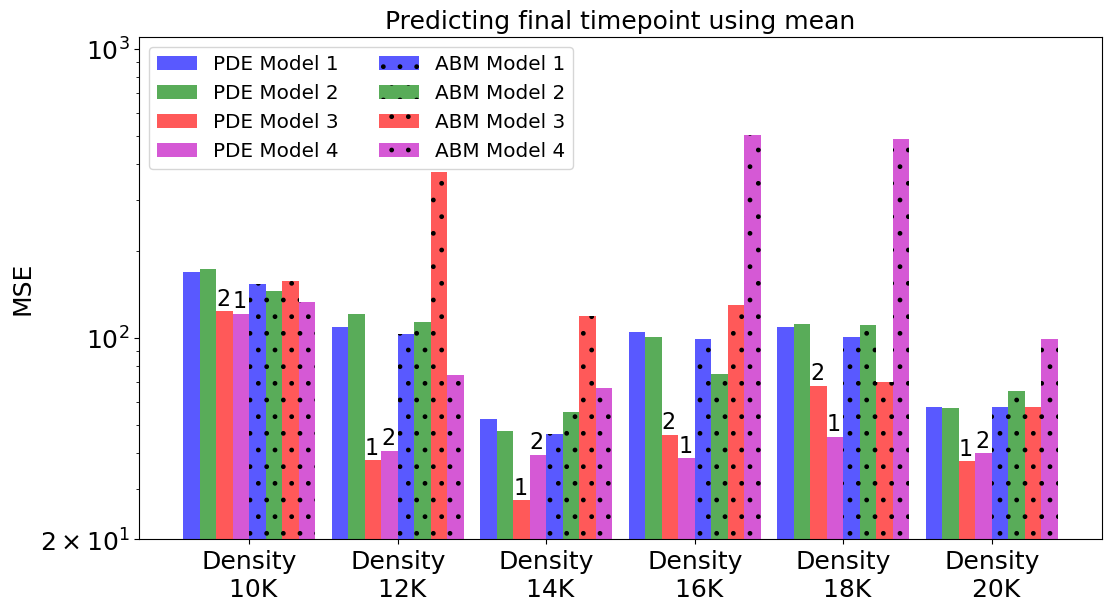

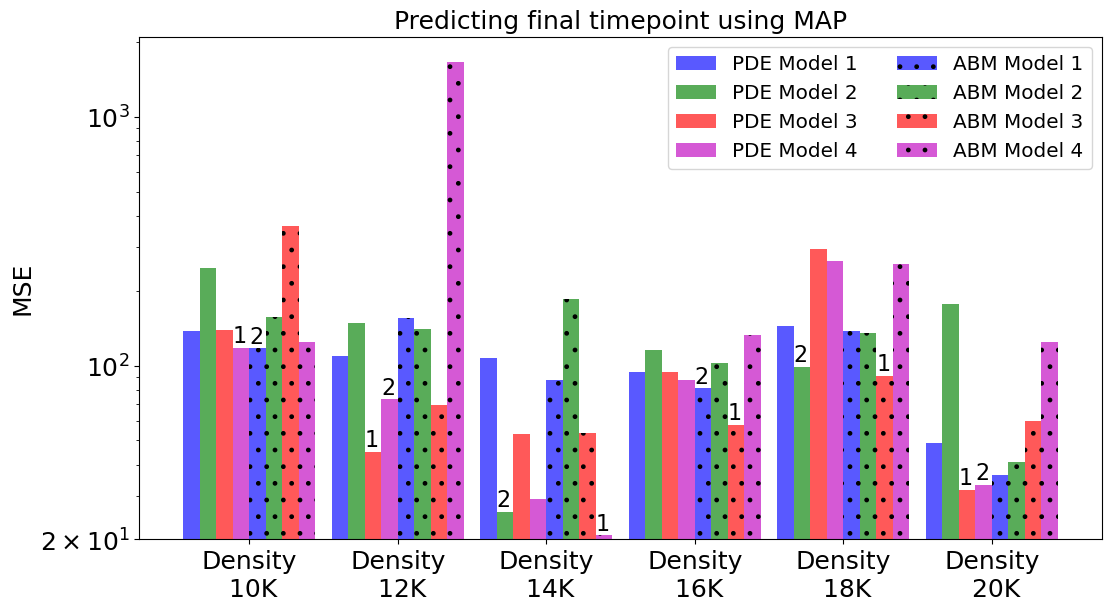

In [16]:
data_type = "WH"
densities = None
pred_type = "pred_final"
dens_ids = range(6)
model_types = ["PDE","ABM"]
parameter_names_list = ["rm_rp","rm_pint_rp","rm_rp_a0_a1","rm_pint_rp_a0_a1"]
best_model_indices_mean = [3, 2, 2, 3, 3, 2]
second_best_model_indices_mean = [2, 3, 3, 2, 2, 3]
best_model_indices_map        = [3, 2, 7, 6, 6, 2]
second_best_model_indices_map = [4, 3, 1, 4, 1, 3]

num_models = len(parameter_names_list)

colors = "bgrm"
fontsize=18

for estimate_type in ["mean","MAP"]:

    # initialize figure
    fig,axes = plt.subplots(1,1,layout="constrained",figsize=(11,6))    

    count = 0
    for dens_id in dens_ids:

        #initialize MSE vals
        PDE_MSEs = []
        ABM_MSEs = []

        #loop over models and type of model
        for parameter_names in parameter_names_list:
            for model_type in model_types:

                #Load in simulation information
                input_parameters = [None, parameter_names, model_type, data_type, dens_id, pred_type]

                (parameter_names, 
                model_type, 
                data_type, 
                dens, 
                simulation,
                initial_perc,
                trueParams,
                delay, 
                lower_bounds,
                upper_bounds,
                indepParams,
                dxs,
                prediction_type,
                priorDir, 
                histogramDir, 
                posteriorDir) = get_parameters_files(input_parameters)

                #load in data
                Data = load_data(data_type, dens=dens, simulation=simulation)

                #load in model prediction (from mean or MAP)
                mat = np.load(f"{posteriorDir}mean_info.npy",allow_pickle=True).item()
                model_prediction = mat[f"{estimate_type}_prediction"]
                if model_type == "ABM":
                    model_prediction = convert_model_to_data_shape(np.mean(model_prediction,axis=0))

                #Compute MSE on final timepoint
                MSE_val = MSE(model_prediction[:,-1],Data[:,-1])

                #store MSE
                if model_type == "PDE":
                    PDE_MSEs.append(MSE_val)
                elif model_type == "ABM":
                    ABM_MSEs.append(MSE_val)
        
        #plot all MSEs
        
        #labels
        if count == 0:
            labels_PDE = [("PDE " + formatted_parameter_names[params]) for params in parameter_names_list]
            labels_ABM = [("ABM " + formatted_parameter_names[params]) for params in parameter_names_list]
        else:
            labels_PDE = None
            labels_ABM = None

        #bar plot for PDE vals
        axes.bar(np.arange(9*count,9*count+num_models),
                 PDE_MSEs,width=1,color=list(colors),alpha=0.65,label=labels_PDE,log=True)

        #bar plot for ABM vals
        axes.bar(np.arange(9*count+num_models,9*count+2*num_models),
                 ABM_MSEs,width=1,color=list(colors),alpha=0.65,hatch=".",label=labels_ABM)

        if estimate_type == "mean":
            best_model_indices = best_model_indices_mean
            second_best_model_indices = second_best_model_indices_mean
        elif estimate_type == "MAP":
            best_model_indices = best_model_indices_map
            second_best_model_indices = second_best_model_indices_map

            
        #Add annotations for best model
        annot_x = 9*count+best_model_indices[count] - 0.4
        try:
            annot_y = 1.05 * PDE_MSEs[best_model_indices[count]]
        except:
            annot_y = 1.05 * ABM_MSEs[best_model_indices[count]-4]
        annot_xy = (annot_x - 0.1 ,annot_y)
        axes.annotate("1",xy=annot_xy,fontsize=16)
        
        #Add annotations for second best model
        annot_x = 9*count+second_best_model_indices[count] - 0.4
        try:
            annot_y = 1.05 * PDE_MSEs[second_best_model_indices[count]]
        except:
            annot_y = 1.05 * ABM_MSEs[second_best_model_indices[count]-4]
        annot_xy = (annot_x - 0.1 ,annot_y)
        axes.annotate("2",xy=annot_xy,fontsize=16)
        
        count += 1

    axes.set_ylabel("MSE",fontsize=fontsize)
    axes.set_title(f"Predicting final timepoint using {estimate_type}",fontsize=fontsize)

    axes.set_xticks([3.5 + 9*i for i in range(6)],[f"Density\n {10 + 2*i}K" for i in range(6)],rotation=0,fontsize=fontsize)

    if estimate_type == "mean":
        axes.set_yticks([2e1, 1e2, 1e3],[r"$2\times10^1$","$10^2$", "$10^3$"],fontsize=fontsize)
        axes.set_ylim([2e1,1.1e3])
    elif estimate_type == "MAP":
        axes.set_yticks([2e1, 1e2, 1e3],[r"$2\times10^1$","$10^2$", "$10^3$"],fontsize=fontsize)
        axes.set_ylim([2e1,2.1e3])

    axes.legend(fontsize=.8*fontsize,ncol=2)
    plt.savefig(f"../../results/Figures/predict_final_timepoint_MSEs_{estimate_type}_{data_type}.png")
    

In [17]:
%load_ext watermark

%watermark -n -u -v -iv -w

Last updated: Mon Jun 08 2026

Python implementation: CPython
Python version       : 3.11.5
IPython version      : 8.15.0

numpy     : 1.25.2
matplotlib: 3.8.0

Watermark: 2.4.3

